## Titanic Dataset
Датасет: [Titanic - Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic/data) (Kaggle), 891 объект, 12 признаков.

**Задача:** обучить модель для предсказания выживаемости пассажиров Титаника по демографическим и билетным данным.

Был проведён EDA: рассмотрен баланс классов, распределения признаков, связь Sex и Pclass с выживаемостью проверена через t-тест и ANOVA (оба показали высокую статистическую значимость, p < 0.001). Обработаны пропуски (Age заполнен медианой, Embarked — модой, Cabin удалена из-за почти полного отсутствия данных), категориальные признаки (Sex, Embarked) закодированы.

Обучены и сравнены 3 модели с настройками по умолчанию: логистическая регрессия (accuracy 0.81), случайный лес (0.80), дерево решений (0.79). Для честного сравнения проведена настройка гиперпараметров через GridSearchCV с 5-кратной кросс-валидацией: случайный лес с подобранными параметрами (max_depth=5, min_samples_split=10, n_estimators=200) поднялся до 0.816 и обошёл логистическую регрессию, для которой оптимальными оказались параметры, близкие к дефолтным. Ограничение глубины деревьев подтвердило, что с настройками по умолчанию ансамбль переобучался на небольшом датасете.

Интересная находка: ANOVA показала высокую значимость Pclass, однако в feature importance Random Forest этот признак оказался внизу списка. Была проверена корреляция между Fare и Pclass — она составила около -0.9, то есть признаки почти дублировали друг друга (мультиколлинеарность), из-за чего важность оказалась "поделена" между ними.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [6]:
df['Survived'].value_counts(normalize=True)
df.groupby('Sex')['Survived'].mean()
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


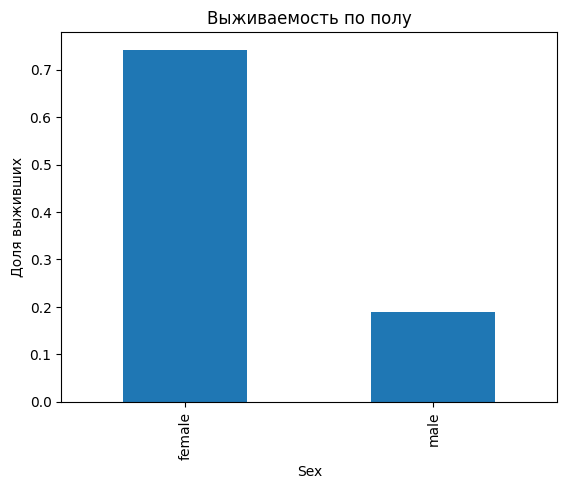

In [7]:
import matplotlib.pyplot as plt
df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title('Выживаемость по полу')
plt.ylabel('Доля выживших')
plt.show()

In [8]:
from scipy import stats

male_survival = df[df['Sex'] == 'male']['Survived']
female_survival = df[df['Sex'] == 'female']['Survived']

t_stat, p_value = stats.ttest_ind(male_survival, female_survival)
print('t-statistic:', t_stat)
print('p_value:', p_value)

t-statistic: -19.297816550123354
p_value: 1.4060661308802594e-69


In [9]:
class1 = df[df['Pclass'] == 1]['Survived']
class2 = df[df['Pclass'] == 2]['Survived']
class3 = df[df['Pclass'] == 3]['Survived']

f_stat, p_value = stats.f_oneway(class1, class2, class3)
print('F-statistic: ', f_stat)
print('p_value: ', p_value)

F-statistic:  57.96481759091002
p_value:  2.183247415118226e-24


In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop('Cabin', axis=1)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df = df.drop(['Name', 'Ticket', 'PassengerId'], axis=1)

In [12]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [13]:
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Descision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  print(f"{name}: accuracy = {acc:.3f}")

Logistic Regression: accuracy = 0.810
Descision Tree: accuracy = 0.788
Random Forest: accuracy = 0.799


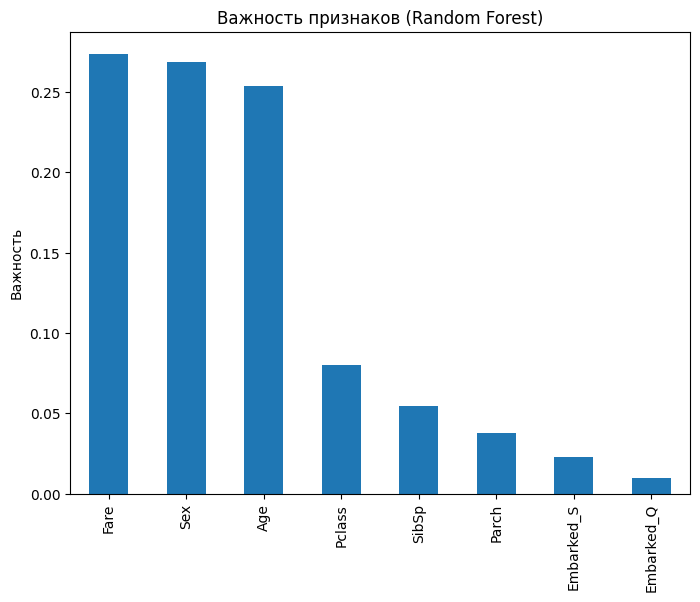

In [14]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
feat_imp.plot(kind='bar')
plt.title('Важность признаков (Random Forest)')
plt.ylabel('Важность')
plt.show()


In [15]:
df[['Fare', 'Sex', 'Age', 'Pclass']].corr()

,Fare,Sex,Age,Pclass
Fare,1.000000,0.182333,0.096688,-0.549500
Sex,0.182333,1.000000,-0.081163,-0.131900
Age,0.096688,-0.081163,1.000000,-0.339898
Pclass,-0.549500,-0.131900,-0.339898,1.000000


In [16]:
from sklearn.metrics import confusion_matrix, classification_report
best_model = models['Logistic Regression']
y_pred_best = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[90 15]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [17]:
X_no_fare = X.drop('Fare', axis=1)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_fare, y, test_size=0.2, random_state=42)

model_test = LogisticRegression(max_iter=1000)
model_test.fit(X_train2, y_train2)
acc_no_fare = accuracy_score(y_test2, model_test.predict(X_test2))
print("Accuracy without Fare: ", acc_no_fare)

Accuracy without Fare:  0.8044692737430168


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [19]:
print('Лучшие параметры: ', grid.best_params_)
print('Лучшая accuracy на кросс-валидации: ', grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print('Accuracy на тесте: ', accuracy_score(y_test, y_pred))

Лучшие параметры:  {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
Лучшая accuracy на кросс-валидации:  0.8314291342460358
Accuracy на тесте:  0.8156424581005587


In [22]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [23]:
print('Лучшие параметры: ', grid_lr.best_params_)
print('Лучшая accuracy на кросс-валидации: ', grid_lr.best_score_)

best_model = grid_lr.best_estimator_
y_pred = best_model.predict(X_test)

print('Accuracy на тесте: ', accuracy_score(y_test, y_pred))

Лучшие параметры:  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Лучшая accuracy на кросс-валидации:  0.7977149610952428
Accuracy на тесте:  0.7877094972067039
